In [15]:
import pandas as pd
from ast import literal_eval
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import re
import json
import glob
from ast import literal_eval
from statistics import mean
plt.rcParams["font.sans-serif"]=["SimHei"] #设置字体
plt.rcParams["axes.unicode_minus"]=False #该语句解决图像中的“-”负号的乱码问题
import matplotlib
print(matplotlib.matplotlib_fname())
print(matplotlib.get_cachedir())

/root/anaconda3/envs/llumnix/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc
/root/.cache/matplotlib


## 分组
将instance.csv中的profiling_data分为开为4列，同时安装instance_id进行分组

In [55]:
def get_profiling_data(filename,):
    instance_log = pd.read_csv(filename)
    # 删除dispatch_load_metric为-inf的行
    instance_log = instance_log[instance_log['dispatch_load_metric'] != -np.inf]

    # 将profiling_data列(inference_type,num_seqs,running_seq_lens,last_inference_latency)中的内容转化为4列
    instance_log[['profiling_inference_type', 'profiling_num_seqs', 'running_seq_lens', 'last_inference_latency']] = (
        instance_log['profiling_data']
        .apply(lambda x: literal_eval(x) if pd.notnull(x) else ("", None, None, None))
        .apply(pd.Series)
    )

    instance_log_group = instance_log.groupby("instance_id")
    # 一个group保存为一个sheet
    with pd.ExcelWriter(filename.replace('.csv', '_metrics.xlsx')) as writer:
        for i, (instance_id, group) in enumerate(instance_log_group):
            group.to_excel(writer, sheet_name=f'Instance_{instance_id}', index=False)

# get_profiling_data('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-t2-pdd-4/llama-7b/poisson/serve_4_tp1_1000_qps_6_instance.csv')
get_profiling_data('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-1/llama-7b/poisson/serve_pdd_2000_qps_6_1,1_2_instance.csv')

/root/anaconda3/envs/llumnix/lib/python3.10/site-packages/openpyxl/workbook/child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


## prefill/第n个token分析
从per_token_latency_breakdown_list提取中提取每个请求的第n个token的各步骤时延

In [52]:

num_req = 2000
qps=12
json_file = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-t2-multi-port-zmp-pdd-4/llama-7b/poisson/benchmark_4_tp1_{num_req}_qps_{qps}_latency_info.json'
json_file = '/workspace/llm-serve/Llumnix/benchmark_test/logs/l40-pdd-hetero/llama-7b/poisson/benchmark_pdd_2000_qps_6_1,1_2_latency_info.json'
json_file = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-16/llama-7b/poisson/benchmark_pdd_2000_qps_6_1,1_2_latency_info.json'
with open(json_file, 'r') as f:
    data = json.load(f)
assert len(data) == 1, "Expected data to contain only one entry"
per_token_latency_breakdown_list = data[0]['per_token_latency_breakdown_list']
# df = pd.DataFrame(per_token_latency_breakdown_list[823])
# df.to_csv(json_file.replace('.json', f'_req_{823}_all.csv'), index=True)
# rows保存每个请求的prefill相关的数据
rows = []
decode_no = 0
for req_idx in range(num_req):
    # 将per_token_latency_breakdown_list[req_idx]的第一行(prefill相关)加入
    tmp = min(len(per_token_latency_breakdown_list[req_idx])-1, decode_no)
    rows.append(per_token_latency_breakdown_list[req_idx][tmp])
df = pd.DataFrame(rows, index=data[0]['request_ids'])
df.to_csv(json_file.replace('.json', f'_decode_{decode_no}.csv'), index=True)
df.head(n=128)
    # df.to_csv(os.path.join('/workspace/llm-serve/Llumnix/logs/l40-pdd--2/llama-2-7b/uniform/' + migrate_backend, f'request_{req_idx}_timestamps.csv'), index=True)

,api_server_generate_timestamp,manager_generate_timestamp,llumlet_generate_timestamp,engine_add_request_timestamp,engine_process_model_outputs_timestamp_begin,engine_process_model_outputs_timestamp_end,engine_step_timestamp_begin,engine_step_timestamp_end,engine_step_postprocess_timestamp_end,engine_put_queue_timestamp,engine_thread_put_queue_timestamp,engine_actor_put_queue_timestamp,queue_client_send_timestamp,queue_server_receive_timestamp,api_server_get_queue_timestamp,api_server_generate_timestamp_end,migrated_add_running_request_start,migrated_add_running_request_end,migrate_out_one_request_begin,migrate_out_one_request_end,across_manager_latency,across_llumlet_latency,across_engine_latency,process_model_outputs_latency,engine_step_latency,step_postprocess_latency,across_async_put_queue_thread_latency,across_async_put_queue_actor_latency,across_queue_client_latency,queue_rpc_latency,api_server_get_queue_latency,across_request_streams_latency,migrate_out_one_request_latency
a56b21e4ee4b41e399796ced972bc4a3,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,0.0,0.0,0.000000e+00,0.0,4.117250,4.879713,3.108263,0.586033,2.628088,0.252008,0.032663,1.449823,0.087738,1.276493,0.263929,0.358582,0.000000e+00
4e11388be4eb452ea8908a1e13484ebd,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,0.0,0.0,0.000000e+00,0.0,4.023314,3.426790,4.206181,0.679016,1.713991,0.395775,0.037909,1.432419,0.139236,1.211643,0.208378,0.257730,0.000000e+00
263458fac64241f9be6c332a4a5cf2d4,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,0.0,0.0,0.000000e+00,0.0,3.918886,3.160715,1.483679,1.431942,2.421618,0.331163,0.045061,1.443148,0.143290,1.068115,0.203371,0.262737,0.000000e+00
71bab4bfd3d142c99cf0b851a04483cf,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,0.0,0.0,1.752487e+09,0.0,4.582167,3.388166,2.901554,0.359535,44.370890,0.473261,0.056744,2.058983,0.146866,1.539946,0.324965,0.431776,-1.752487e+12
219a54f6de0d4415a7b18586abac4387,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,0.0,0.0,0.000000e+00,0.0,3.905773,3.232002,2.466440,0.637770,2.593994,0.256538,0.033617,1.497746,0.100136,1.107693,0.218868,0.264406,0.000000e+00
a0eab5095c4542e587ac6b114d7ac7c4,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,0.0,0.0,0.000000e+00,0.0,5.527496,6.002903,0.933170,0.916958,2.006531,0.582457,0.052929,1.493454,0.829697,0.940323,0.208378,0.264406,0.000000e+00
ccd6cb9bafe044ca891accdec531e920,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,0.0,0.0,0.000000e+00,0.0,3.734112,3.101110,3.220558,0.662088,1.668215,0.409365,0.039577,1.393080,0.141144,1.340151,0.251770,0.864744,0.000000e+00
9c6259726b2b44c8b2226b0e9d46e48f,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,1.752487e+09,0.0,0.0,0.000000e+00,0.0,4.068136,3.316879,1.078606,0.

## 获取请求的各个token时延和迁移时间

In [59]:
import re
def plot_single(ax, latencies):
    hist, bin_edges = np.histogram(latencies, bins=50)
    cumsum = np.cumsum(hist)
    p50 = np.percentile(latencies, 50)
    p80 = np.percentile(latencies, 80)
    p95 = np.percentile(latencies, 95)
    p99 = np.percentile(latencies, 99)
    p999 = np.percentile(latencies, 99.9)
    print(f'p50:{p50},p80:{p80},p95:{p95},p99:{p99},p999:{p999}')
    ax.plot(bin_edges[1:], cumsum/np.sum(hist)*100, color='red')
    ax.axvline(p50, color='blue', linestyle='--', label='P50')
    ax.text(p50, ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]), f"{p50:.2f}", va='bottom', ha='right', color='blue')
    ax.axvline(p80, color='green', linestyle='--', label='P80')
    ax.text(p80, ax.get_ylim()[0] + 0.10 * (ax.get_ylim()[1] - ax.get_ylim()[0]), f"{p80:.2f}", va='bottom', ha='right', color='green')
    ax.axvline(p95, color='orange', linestyle='--', label='P95')
    ax.text(p95, ax.get_ylim()[0] + 0.15 * (ax.get_ylim()[1] - ax.get_ylim()[0]), f"{p95:.2f}", va='bottom', ha='right', color='orange')
    ax.axvline(p99, color='purple', linestyle='--', label='P99')
    ax.text(p99, ax.get_ylim()[0] + 0.20 * (ax.get_ylim()[1] - ax.get_ylim()[0]), f"{p99:.2f}", va='bottom', ha='right', color='purple')
    ax.axvline(p999, color='gray', linestyle='--', label='P99.9')
    ax.text(p999, ax.get_ylim()[0] + 0.25 * (ax.get_ylim()[1] - ax.get_ylim()[0]), f"{p999:.2f}", va='bottom', ha='right', color='gray')
    mean = np.mean(latencies)
    mean_value = bin_edges[:-1][np.where(bin_edges[:-1] <= mean)][-1]
    mean_percentage = cumsum[np.where(bin_edges[:-1] <= mean)][-1] / np.sum(hist) * 100
    ax.axvline(mean_value, color='black', linestyle='-', label='mean={:.2f}'.format(mean))
    ax.text(mean_value, mean_percentage, f"{mean_percentage:.2f}", va='bottom', ha='right', color='black')
    ax.legend(loc='upper right')
    ax.set_ylabel('Cumulative Percentage(%)')
def extract_migration_times(path):
    # 检查文件是否存在
    if not os.path.isfile(path):
        print(f"File {path} does not exist.")
        return {}
    # 初始化结果字典
    migration_times = {}

    # 正则表达式模式（保持不变）
    pattern = r'migrate request \[(.*?)\].*?cost: (\d+\.\d+) ms'

    # 逐行读取文件（自动处理大文件）
    with open(path, 'r', encoding='utf-8') as file:
        for line in file:
            # 直接处理每行（更高效）
            line = line.strip()  # 移除首尾空白字符
            if 'migrate done' in line and 'cost:' in line:
                match = re.search(pattern, line)
                if match:
                    # 提取请求ID和时间（逻辑不变）
                    ids_str = match.group(1)
                    time = float(match.group(2))
                    request_ids = [req_id.strip("'") for req_id in ids_str.split(', ')]
                    # 更新字典
                    for req_id in request_ids:
                        migration_times[req_id] = time
    return migration_times

def extract_migration_waiting_times(log_file_path, is_plot=False):
    # 定义一个字典，用于存储请求 ID 对应的时间戳
    request_timestamps = {}
    migrate_waiting_times = []
    # 打开日志文件并逐行读取
    with open(log_file_path, 'r') as file:
        for line in file:
            # 检查行是否包含 engine_step_timestamp_end 或 _migrate_out_one_request start
            if "engine_step_timestamp_end" in line or "_migrate_out_one_request start" in line \
                  or "MigrationStatus.ABORTED_DST, timestamps" in line \
                    or "MigrationStatus.ABORTED_SRC, timestamps" in line :
                # 使用正则表达式提取请求 ID
                request_id_match = re.search(r'[0-9a-f]{32}', line)
                # 使用正则表达式提取时间戳
                timestamp_match = re.search(r'timestamps: \d+\.\d+', line)

                if request_id_match and timestamp_match:
                    request_id = request_id_match.group()
                    timestamp = float(timestamp_match.group().split(":")[1])

                    # 如果请求 ID 不在字典中，则初始化一个条目
                    if request_id not in request_timestamps:
                        request_timestamps[request_id] = {
                            "engine_step_timestamp_end": None,
                            "_migrate_out_one_request start": None,
                            "migrate_start_count": 0,
                            "ABORTED_DST_count":0,
                            "ABORTED_SRC_count":0,
                        }

                    # 根据日志行内容更新对应的时间戳
                    if "engine_step_timestamp_end" in line:
                        request_timestamps[request_id]["engine_step_timestamp_end"] = timestamp
                    elif "_migrate_out_one_request start" in line:
                        request_timestamps[request_id]["_migrate_out_one_request start"] = timestamp
                        request_timestamps[request_id]["migrate_start_count"] += 1
                    elif "MigrationStatus.ABORTED_DST, timestamps" in line:
                        request_timestamps[request_id]["ABORTED_DST_count"] += 1
                    elif "MigrationStatus.ABORTED_SRC, timestamps" in line:
                        request_timestamps[request_id]["ABORTED_SRC_count"] += 1
                        
                    if request_timestamps[request_id]["_migrate_out_one_request start"] is not None and request_timestamps[request_id]["engine_step_timestamp_end"] is not None:
                        request_timestamps[request_id]["migrate_waiting_time"] = (request_timestamps[request_id]["_migrate_out_one_request start"] - request_timestamps[request_id]["engine_step_timestamp_end"]) *1000
                        request_timestamps[request_id]["migrate_waiting_time"] = max(0, request_timestamps[request_id]["migrate_waiting_time"])
                        migrate_waiting_times.append(request_timestamps[request_id]["migrate_waiting_time"])
    
    if is_plot and len(migrate_waiting_times) > 0:
        fig, (ax) = plt.subplots(1, 1, figsize=(7, 4.8))
        fig.suptitle(log_file_path, fontsize=14)
        plot_single(ax, migrate_waiting_times)
        
    return request_timestamps


In [7]:

def json_to_decode_latencies(json_file, csv_file, log_file=None):
    with open(json_file, 'r') as f:
        data = json.load(f)
    # 提取指定字段
    token_latencies_list = data[0]['all_decode_token_latencies']
    response_lens = data[0]['request_lens']
    # token_latencies_list是一个list，response_lens保存了每个请求在token_latencies_list中对应的长度，基于response_lens将其转换为二维数组
    output_len_per_seq = max(response_lens)
    token_latencies = np.zeros((len(response_lens), output_len_per_seq))

    t=0
    for i in range(len(response_lens)):
        token_latencies[i][:response_lens[i]] = token_latencies_list[t:t+response_lens[i]]
        # assert token_latencies[i][0] != token_latencies[i][1], f"token_latencies[{i}][0]== token_latencies[{i}][1] = {token_latencies[i][0]} == {token_latencies[i][1]}"
        if token_latencies[i][0] == token_latencies[i][1]:
            print(f"token_latencies[{i}][0] == token_latencies[{i}][1] = {token_latencies[i][0]} == {token_latencies[i][1]}")
        t += response_lens[i]
    
    # 将数据转换为DataFrame，将request_ids作为index
    df = pd.DataFrame(token_latencies, index=data[0]['request_ids'])

    # 设置列名为token_id
    df.columns = [f'decode_token_{i+1}' for i in range(output_len_per_seq)]

    # 获取迁移时间
    if 'pdd' in json_file.split('/')[-1]:
        if log_file is None:
            # 将'/workspace/llm-serve/Llumnix/logs/l40-pdd--2/llama-2-7b/poisson/benchmark_pdd_tp1_1000_qps_4_prompt_len_1024_response_len_64_1_1_latency_info.json'转化为'/workspace/llm-serve/Llumnix/logs/l40-pdd--2/llama-2-7b/poisson/benchmark_pdd_tp1_1000_qps_4_1_1_prompt_len_1024_response_len_64_latency_info.json'
            p_d = json_file[-22:-17]    # _1_1_
            tmp = json_file[:-22].split('qps_')
            tmp = tmp[0] + 'qps_' + tmp[1][0] + p_d + tmp[1][2:] + json_file[-17:]
            log_path = tmp.replace('_latency_info.json', '.log')
            # 将最后一个'benchmark'替换为'serve'
            if 'benchmark' in log_path:
                log_path = re.sub(r'benchmark(?!.*benchmark)', 'serve', log_path)
            print(log_path)
            # log_path = log_path.replace('benchmark', 'serve')
        else:
            log_path = log_file
        
        migration_times = extract_migration_times(log_path)
        migration_waiting_times = extract_migration_waiting_times(log_path)
        # print(log_path,len(migration_times))

        # 在df中添加一列，列名为migration_time，放在第一列
        df.insert(0, 'migration_time', 0.0)
        df.insert(0, 'migration_waiting_time', 0.0)
        # 遍历df的index，获取对应的migration_time
        for index in df.index:
            # 如果index在migration_times中，则将对应的值赋值给df['migration_time']
            # print(index, index in migration_times)
            if index in migration_times:
                df.at[index, 'migration_time'] = migration_times[index]

            if index in migration_waiting_times and "migrate_waiting_time" in migration_waiting_times[index]:
                # print(migration_waiting_times[index])
                df.at[index, 'migration_waiting_time'] = migration_waiting_times[index]['migrate_waiting_time']
        # 绘制迁移时间和迁移等待时间的直方图
        if len(df['migration_time']) > 0:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 4.8))
            fig.suptitle(log_file, fontsize=14)
            plot_single(ax1, df['migration_time'])
            ax1.set_title('Migration Time Distribution')
            plot_single(ax2, df['migration_waiting_time'])
            ax2.set_title('Migration Waiting Time Distribution')
            plt.tight_layout()
            plt.savefig(json_file.replace('.json', '_migration_times.png'))
            plt.close(fig)

    # print(csv_file)
    df.insert(0, 'prefill_time', data[0]['prefill_token_latencies'])
    # 保存为csv文件
    df.to_csv(csv_file, index=True)

# glob.glob(os.path.join(dir, '*.json'))
filenames = [
    # '/workspace/llm-serve/Llumnix/benchmark_test/logs/l40-pdd-hetero/llama-7b/poisson/benchmark_pdd_2000_qps_6_1,1_2_latency_info.json',
    '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-1/llama-7b/poisson/benchmark_pdd_2000_qps_4_1,1_2_latency_info.json'
]
log_filenames = [
    '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-1/llama-7b/poisson/serve_pdd_2000_qps_4_1,1_2.log'
]
for filename, log_file in zip(filenames, log_filenames):
    
    output_path = filename.replace('latency_info.json', 'all_decode_token_latencies.csv')
    if os.path.exists(output_path):
        continue
    print(filename)
    json_to_decode_latencies(filename, output_path, log_file=log_file)

/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-1/llama-7b/poisson/benchmark_pdd_2000_qps_4_1,1_2_latency_info.json


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

## 获取迁移相关信息

In [61]:
def extract_migration_info(path, file_output, tp_hetero=False, verbose=False):
    '''
    migration_info[req_id] = {
                            "blocks": blocks,
                            "time_ms": migrate time,
                            "speed_blocks_per_s": speed
                            "migrate_waiting_time": migrate_waiting_time(ms)
                        }
    '''
    print(f"Processing log file: {path}")
    if file_output is None:
        file_output = open('/tmp/benchmark_tmp', "w")
    file_output.write(f"Processing log file: {path}")

    # 检查文件是否存在
    if not os.path.isfile(path):
        file_output.write(f"File {path} does not exist.")
        return {}

    migration_info = {}
    reject_migrate_in_count = 0
    reject_migrate_out_count = 0
    # 示例： Instance ... migrate done, migrate request ['494c45676def4572986621d1afbc337f'], migration status: MigrationStatus.FINISHED, len: 7 blocks, cost: 240.65113067626953 ms
    # 正确的正则表达式应为：
    pattern = r"migrate request \[(.*?)\].*?len: (\d+) blocks,.*?cost: ([\d\.]+) ms"
    count = 0
    finished_flag = False
    if not tp_hetero:
        finished_str = "Entrypoints num_finished_requests: 503"
    else:
        finished_str = "Entrypoints num_finished_requests: 671"
    # 逐行读取文件（自动处理大文件）
    with open(path, 'r', encoding='utf-8') as file:
        for line in file:
            line = line.strip()
            # if "Error" in line:
            #     print(f"Error in line:{line}")
            
            if finished_str in line:
                finished_flag = True
            if 'reject new migrate out' in line:
                reject_migrate_out_count += 1
            if 'reject new migrate in' in line:
                reject_migrate_in_count += 1
            # 获取迁移时间和速度
            if 'migrate done' in line and 'cost:' in line:
                if count < 10:
                    count += 1
                    continue
                match = re.search(pattern, line)
                if match:
                    ids_str = match.group(1)
                    blocks = int(match.group(2))
                    time = float(match.group(3))
                    speed = blocks / time * 1000 if time > 0 else 0  # blocks/ms -> blocks/s
                    request_ids = [req_id.strip("'") for req_id in ids_str.split(', ')]
                    for req_id in request_ids:
                        if len(req_id) > 0:
                            assert req_id in migration_info, f"{req_id},{type(req_id)},{line}"
                            migration_info[req_id]["blocks"] = blocks
                            migration_info[req_id]["time_ms"] = time
                            migration_info[req_id]["speed_blocks_per_s"] = speed

            if "engine_step_timestamp_end" in line or "_migrate_out_one_request start" in line \
                  or "MigrationStatus.ABORTED_DST, timestamps" in line \
                    or "MigrationStatus.ABORTED_SRC, timestamps" in line :
                # 使用正则表达式提取请求 ID
                request_id_match = re.search(r'[0-9a-f]{32}', line)
                # 使用正则表达式提取时间戳
                timestamp_match = re.search(r'timestamps: \d+\.\d+', line)

                if request_id_match and timestamp_match:
                    request_id = request_id_match.group()
                    timestamp = float(timestamp_match.group().split(":")[1])

                    # 如果请求 ID 不在字典中，则初始化一个条目
                    if request_id not in migration_info:
                        migration_info[request_id] = {
                            "blocks": 0,
                            "time_ms":  0.0,
                            "speed_blocks_per_s": 0.0,
                            "engine_step_timestamp_end": None,
                            "migrate_out_one_request_start": None,
                            "migrate_start_count": 0,
                            "ABORTED_DST_count":0,
                            "ABORTED_SRC_count":0,
                        }

                    # 根据日志行内容更新对应的时间戳
                    if "engine_step_timestamp_end" in line:
                        migration_info[request_id]["engine_step_timestamp_end"] = timestamp
                    if migration_info[request_id]["time_ms"] == 0.0:
                        if "_migrate_out_one_request start" in line:
                            migration_info[request_id]["migrate_out_one_request_start"] = timestamp
                            migration_info[request_id]["migrate_start_count"] += 1
                        elif "MigrationStatus.ABORTED_DST, timestamps" in line:
                            migration_info[request_id]["ABORTED_DST_count"] += 1
                        elif "MigrationStatus.ABORTED_SRC, timestamps" in line:
                            migration_info[request_id]["ABORTED_SRC_count"] += 1
                            
                        if migration_info[request_id]["migrate_out_one_request_start"] is not None and migration_info[request_id]["engine_step_timestamp_end"] is not None:
                            migration_info[request_id]["migrate_waiting_time"] = (migration_info[request_id]["migrate_out_one_request_start"] - migration_info[request_id]["engine_step_timestamp_end"]) *1000
                            migration_info[request_id]["migrate_waiting_time"] = max(0, migration_info[request_id]["migrate_waiting_time"])
                            # migrate_waiting_times.append(migration_info[request_id]["migrate_waiting_time"])
                    else:
                        # print("not first migration")
                        pass

    fail_req_id = set()
    for req_id, info in migration_info.items():
        if 'migrate_waiting_time' not in migration_info[req_id]:
            fail_req_id.add(req_id)
            if verbose:
                file_output.write(f'fail req_id:{req_id}, no migrate_waiting_time, {migration_info[req_id]}')
        else:
            if migration_info[req_id]["migrate_waiting_time"] > 1000:
                pass
                # file_output.write(f'req_id:{req_id},migrate_waiting_time:{migration_info[req_id]["migrate_waiting_time"]},ABORTED_DST_count:{migration_info[req_id]["ABORTED_DST_count"]}')
        if migration_info[req_id]['time_ms'] == 0.0:
            fail_req_id.add(req_id)
            if verbose:
                file_output.write(f'fail req_id:{req_id}, no migrate_time, {migration_info[req_id]}')
    for req_id in fail_req_id:
        del migration_info[req_id]
    
    if migration_info:
        avg_speed = mean(info['speed_blocks_per_s'] for info in migration_info.values())
        avg_migration_time = mean(info['time_ms'] for info in migration_info.values())
        avg_migrate_waiting_time = mean(info["migrate_waiting_time"] for info in migration_info.values())
        avg_migration_count = mean(info['migrate_start_count'] for info in migration_info.values())
        avg_migration_aborted_dst_count = mean(info['ABORTED_DST_count'] for info in migration_info.values())

        file_output.write(f"fail req num(lose msg): {len(fail_req_id)}, finished_flag:{finished_flag},finished_str:{finished_str}")
        file_output.write(f"Average migration speed: {avg_speed:.2f} blocks/s")
        file_output.write(f"Average migration time: {avg_migration_time:.2f} ms")
        file_output.write(f'Average migration waiting time: {avg_migrate_waiting_time:.2f} ms')
        file_output.write(f"Average migration count: {avg_migration_count}")
        file_output.write(f"Average migration ABORTED_DST count: {avg_migration_aborted_dst_count}")
        file_output.write(f"Sum migration ABORTED_DST count: {avg_migration_aborted_dst_count*len(migration_info)}")
        file_output.write(f"reject_migrate_out_count:{reject_migrate_out_count}")
        file_output.write(f"reject_migrate_in_count:{reject_migrate_in_count}")
        file_output.write(f"max block num : {max(info['blocks'] for info in migration_info.values())}")
        # if avg_migration_count > avg_migration_aborted_dst_count + 
        for req_id, info in migration_info.items():
            info['avg_speed_blocks_per_s'] = avg_speed
    else:
        file_output.write("No migration information found.")

    file_output.write("\n")
    assert finished_flag
    res = {
        'avg_speed': avg_speed,
        'avg_migration_time': avg_migration_time,
        'avg_migrate_waiting_time': avg_migrate_waiting_time,
        'avg_migration_count': avg_migration_count,
        'avg_migration_aborted_dst_count': avg_migration_aborted_dst_count,
        'sum_migration_aborted_dst_count': avg_migration_aborted_dst_count*len(migration_info),
        'reject_migrate_out_count': reject_migrate_out_count,
        'reject_migrate_in_count': reject_migrate_in_count,
    }
    return res


In [24]:

path_tmp = 'A6000-2-formal2'
model = 'llama-13b'
max_concurrent = 16
instance_num = 4
qps = [2,4]
# log_paths = [
#     '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal-concurrency-8-pdd-4/llama-7b/poisson/serve_pdd_tp1_2000_qps_2_1_3.log'
# ]
output_file = f"output-{path_tmp}-{model}-max_concurrent_{max_concurrent}.txt"
if os.path.isfile(output_file):
    os.remove(output_file)
with open(output_file, "w") as file:
    for q in qps:
        for prefill_num in range(1,instance_num):
            decode_num = instance_num-prefill_num
            log_path = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/{path_tmp}-concurrency-{max_concurrent}-pdd-4/{model}/poisson/serve_pdd_tp1_2000_qps_{q}_{prefill_num}_{decode_num}.log'
    # for log_path in log_paths:
            
            # 调用函数提取迁移速度
            extract_migration_info(log_path, file)
        log_path = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/{path_tmp}-pdd-hetero-concurrency-{max_concurrent}/{model}/poisson/serve_pdd_2000_qps_{q}_1,1_2.log'
        extract_migration_info(log_path, file, True)


## 获取较为宏观的信息(时延和迁移相关信息)

In [56]:
def get_lantency(json_file):
    if not os.path.isfile(json_file):
        print(f"File {json_file} does not exist.")
        return None
    print(f'Process file: {json_file}')
    try:
        with open(json_file, 'r') as f:
            data = json.load(f)
    except Exception as e:
        print(f'error:{str(e)}')
    assert len(data) == 1, "Expected data to contain only one entry"
    latencies = data[0]
    req_latencies, prefill_latencies, decode_latencies = latencies['request_latencies'], latencies['prefill_token_latencies'], latencies['decode_token_latencies']
    return round(mean(req_latencies), 2), round(mean(prefill_latencies), 2), round(mean(decode_latencies), 2)

path_tmp = 'A6000-2-formal2'
model = 'llama-13b'
concurrencies = [1,2,4,8,16]
instance_num = 4
qps = [2,4]
json_file = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-13b/poisson/benchmark_4_tp1_2000_qps_2_latency_info.json'
# for concurrency in concurrencies:
#     for q in qps:
#         json_file = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/{path_tmp}-concurrency-{concurrency}-pdd-{instance_num}/{model}/poisson/benchmark_{instance_num}_tp1_2000_qps_{q}_latency_info.json'
#         print(get_lantency(json_file))
#         for prefill_num in range(1,instance_num):
#             decode_num = instance_num-prefill_num
#             json_file = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/{path_tmp}-concurrency-{concurrency}-pdd-{instance_num}/{model}/poisson/benchmark_pdd_tp1_2000_qps_{q}_{prefill_num}_{decode_num}_latency_info.json'
#             print(get_lantency(json_file))
#         json_file = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/{path_tmp}-pdd-hetero-concurrency-{concurrency}/{model}/poisson/benchmark_pdd_2000_qps_{q}_1,1_2_latency_info.json'
#         print(get_lantency(json_file))

In [62]:
import pandas as pd
import pickle
def get_label(prefill_tps, decode_tps, is_pd=True):
    if not is_pd:
        res = ",".join(str(x) for x in prefill_tps)
    else:
        res = ",".join(str(x) for x in prefill_tps) + '-' + ",".join(str(x) for x in decode_tps)
    return res

path_tmp = 'A6000-2-formal2'
model = 'llama-7b'
instance_num = 4
if model == 'llama-7b':
    concurrencies = [1,2,4,8,16]
    qps = [2,4,6,8,10,12]
elif model == 'llama-13b':
    concurrencies = [1,2,4,8,16]
    qps = [1,2,4,]
results = {}            # {(qps, concurrency): (req, prefill, decode)}
migration_infos = {}    # {(qps, concurrency): migration_info}
labels = []             # 延迟的label，用于区分不同资源分配下的latency (3*(instance_num+1)个)
migration_labels = []   # 迁移数据的label，instance_num个，如1-1,1,1、1,1-1,1、1,1,1-1、1,1-2)
cache_file = f'latency_results_cache-{path_tmp}-{model}-{concurrencies}-{qps}.pkl'
result_file = f'latency_results-{path_tmp}-{model}-{concurrencies}-{qps}.xlsx'
migration_infos_file = f'migration_infos-{path_tmp}-{model}-{concurrencies}-{qps}.xlsx'

# 如果有缓存文件则直接加载
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        data_res = pickle.load(f)
        print(data_res.keys())
        results = data_res['results']
        label = data_res['labels']
        migration_infos = data_res['migration_infos'] if 'migration_infos' in data_res else {}
        migration_labels = data_res['migration_labels'] if 'migration_labels' in data_res else []

for q in qps:
    for concurrency in concurrencies:
        if (q, concurrency) in results:
            continue
        result = []
        json_file = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/{path_tmp}-concurrency-{concurrency}-pdd-{instance_num}/{model}/poisson/benchmark_{instance_num}_tp1_2000_qps_{q}_latency_info.json'
        result.extend(get_lantency(json_file))
        
        for prefill_num in range(1,instance_num):
            decode_num = instance_num-prefill_num
            json_file = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/{path_tmp}-concurrency-{concurrency}-pdd-{instance_num}/{model}/poisson/benchmark_pdd_tp1_2000_qps_{q}_{prefill_num}_{decode_num}_latency_info.json'
            result.extend(get_lantency(json_file))
            labels.extend(get_label([1]*prefill_num, [1]*decode_num))
        json_file = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/{path_tmp}-pdd-hetero-concurrency-{concurrency}/{model}/poisson/benchmark_pdd_2000_qps_{q}_1,1_2_latency_info.json'
        result.extend(get_lantency(json_file))
        results[(q, concurrency)] = result
        # 保存结果到本地
        with open(cache_file, 'wb') as f:
            data_res = {}
            data_res['results'] = results
            data_res['labels'] = labels
            data_res['migration_infos'] = migration_infos
            data_res['migration_labels'] = migration_labels
            pickle.dump(data_res, f)
            
for q in qps:
    for concurrency in concurrencies:
        if (q, concurrency) in migration_infos:
            continue
        migration_info = {}
        for prefill_num in range(1,instance_num):
            decode_num = instance_num - prefill_num
            log_path = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/{path_tmp}-concurrency-{concurrency}-pdd-4/{model}/poisson/serve_pdd_tp1_2000_qps_{q}_{prefill_num}_{decode_num}.log'

            # 调用函数提取迁移信息
            info = extract_migration_info(log_path, None)
            migration_info[get_label([1]*prefill_num, [1]*decode_num)] = info
        log_path = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/{path_tmp}-pdd-hetero-concurrency-{concurrency}/{model}/poisson/serve_pdd_2000_qps_{q}_1,1_2.log'
        info = extract_migration_info(log_path, None, True)
        migration_info[get_label([1]*2, [2]*1)] = info
            
        migration_infos[(q, concurrency)] = migration_info
labels=[]
labels.extend([get_label([1]*instance_num, 0, False)]*3)
for prefill_num in range(1,instance_num):
    decode_num = instance_num-prefill_num
    labels.extend([get_label([1]*prefill_num, [1]*decode_num)]*3)
labels.extend([get_label([1]*2, [2]*1)]*3)

migration_labels=[]
for prefill_num in range(1,instance_num):
    decode_num = instance_num-prefill_num
    migration_labels.extend([get_label([1]*prefill_num, [1]*decode_num)])
migration_labels.extend([get_label([1]*2, [2]*1)])

# 保存结果到本地
with open(cache_file, 'wb') as f:
    data_res = {}
    data_res['results'] = results
    data_res['labels'] = labels
    
    for q in qps:
        for  concurrency in concurrencies:
            if '1,1-1' in migration_infos[(q, concurrency)] or '1-1' in migration_infos[(q, concurrency)]:
                # migration_infos[(q, concurrency)]['1-1,1,1'] = migration_infos[(q, concurrency)]['1-1']
                # migration_infos[(q, concurrency)]['1,1-1,1'] = migration_infos[(q, concurrency)]['1,1-1']
                del migration_infos[(q, concurrency)]['1,1-1']
                del migration_infos[(q, concurrency)]['1-1']
    data_res['migration_infos'] = migration_infos
    data_res['migration_labels'] = migration_labels
    pickle.dump(data_res, f)
print(len(labels))
with pd.ExcelWriter(result_file) as writer:
    for q in qps:
        # 构造以 concurrency 为行，latency 为列的 DataFrame
        data = [results[(q, concurrency)] for concurrency in concurrencies]
        df_qps = pd.DataFrame(data, index=concurrencies, columns=labels)
        df_qps.index.name = 'concurrency'
        df_qps.to_excel(writer, sheet_name=f'qps_{q}')
metrics = ['avg_speed',
        'avg_migration_time',
        'avg_migrate_waiting_time',
        'avg_migration_count',
        'avg_migration_aborted_dst_count',
        'sum_migration_aborted_dst_count',
        'reject_migrate_out_count',
        'reject_migrate_in_count',
    ]

with pd.ExcelWriter(migration_infos_file) as writer:
    for metric in metrics:
        for q in qps:
            # 构造以 concurrency 为行，latency 为列的 DataFrame
            data = [migration_infos[(q, concurrency)] for concurrency in concurrencies]
            data_all = []
            for single_data in data:
                data_cur_concurrency = []
                
                for label in migration_labels:
                    data_cur_concurrency.append(single_data[label][metric])
                data_all.append(data_cur_concurrency)
            df_qps = pd.DataFrame(data_all, index=concurrencies, columns=migration_labels)
            df_qps.index.name = 'concurrency'
            df_qps.to_excel(writer, sheet_name=f'qps_{q}_{metric}')

dict_keys(['results', 'labels', 'migration_infos', 'migration_labels'])
Processing log file: /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-7b/poisson/serve_pdd_tp1_2000_qps_10_1_3.log
Processing log file: /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-7b/poisson/serve_pdd_tp1_2000_qps_10_2_2.log
Processing log file: /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-7b/poisson/serve_pdd_tp1_2000_qps_10_3_1.log
Processing log file: /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-1/llama-7b/poisson/serve_pdd_2000_qps_10_1,1_2.log
Processing log file: /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-2-pdd-4/llama-7b/poisson/serve_pdd_tp1_2000_qps_10_1_3.log
Processing log file: /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-2-pdd-4/llama-7b/poisson/serve_pdd_tp1_200

In [26]:
def get_step_lantency(json_file):
    if not os.path.isfile(json_file):
        print(f"File {json_file} does not exist.")
        return None
    print(f'Process file: {json_file}')
    try:
        with open(json_file, 'r') as f:
            data = json.load(f)
    except Exception as e:
        print(f'error:{str(e)}')
    assert len(data) == 1, "Expected data to contain only one entry"
    per_token_latency_breakdown_list = data[0]['per_token_latency_breakdown_list']
    prefill_waiting_time = [(per_token_latency_breakdown_list[i][0]['engine_step_timestamp_begin'] - per_token_latency_breakdown_list[i][0]['engine_add_request_timestamp'])*1000
                             for i in range(len(per_token_latency_breakdown_list))]
    engine_step_latency_prefill = [per_token_latency_breakdown_list[i][0]['engine_step_latency'] for i in range(len(per_token_latency_breakdown_list))]
    engine_step_latency_decode = [
        mean([token['engine_step_latency'] for token in per_token_latency_breakdown_list[i][1:]])
        if len(per_token_latency_breakdown_list[i][1:]) > 0 else None
        for i in range(len(per_token_latency_breakdown_list))
    ]

    return round(mean(prefill_waiting_time), 2), round(mean(engine_step_latency_prefill), 2), round(mean([x for x in engine_step_latency_decode if x is not None]), 2)
json_file = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-4/llama-13b/poisson/benchmark_pdd_2000_qps_1_1,1_2_latency_info.json'
get_step_lantency(json_file)

Process file: /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-4/llama-13b/poisson/benchmark_pdd_2000_qps_1_1,1_2_latency_info.json


(103.76, 4.61, 44.75)

## 汇总
上文提到的大多数信息，均可以通过main.py获得

In [22]:
from main import LogAnalysis

# 提取信息
model = 'llama-13b' # 'llama-7b'
analysis = LogAnalysis(model)
analysis.get_all_msg()  # 首次需要
# 结果保存在 analysis.results 中，[concurrency][qps][label]

# data_to_show = {
#     'concurrency': str(16),
#     'qps': str(6),
#     'labels': ["1,1-1,1",  "1,1-2"]# ["1,1,1,1", "1-1,1,1", "1,1-1,1", "1,1,1-1", "1,1-2"]
# }

def get_value(key, fix_fields, change_field_value):
    if key in fix_fields:
        return str(fix_fields[key])
    else:
        return str(change_field_value)
fix_fields = {
    'qps': str(1),
    # 'labels': "1,1,1,1"
    'concurrency': 4 # [1,2,4,8,16]
}
change_field = {
    'labels': ["1,1,1,1", "1-1,1,1", "1,1-1,1", "1,1,1-1", "1,1-2"]
}

assert len(change_field) == 1

data = []
key = list(change_field.keys())[0]
values = list(change_field.values())[0]
for v in values:
    concurrency = get_value('concurrency', fix_fields, v)
    qps = get_value('qps', fix_fields, v)
    label = get_value('labels', fix_fields, v)
    data.append(analysis.results[concurrency][qps][label])
# 显示所有列
pd.set_option('display.max_columns', None)
# 显示所有行
pd.set_option('display.max_rows', None)
# 设置每列宽度（可选）
pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(data, index=[f'{key}_{v}' for v in values])
df

[LogAnalysis] exist cache_file:latency_results_cache-A6000-2-formal2-llama-13b-[1, 2, 4, 8, 16]-[1, 2, 4].json


,request_time,prefill_time,decode_time,prefill_waiting_time,prefill_step_time,decode_step_time,16f27308d2a14507b537e1551d7175b2,54d7737a2298495eb2f68d6c641f67ba,606b88ae1c8f498892e9407613391c0c,758aec7a307d480c85c5417eb08dfc83,avg_speed,avg_migration_time,avg_migrate_waiting_time,avg_migration_count,avg_migration_aborted_dst_count,sum_migration_aborted_dst_count,reject_migrate_out_count,reject_migrate_in_count,7dbd01462a4a4ef6a3e25dc58287e298,a5593f816a284fa99a569499627b2b78,c1084cf740234521a4bbc1213ebb9e49,c29e0bfcd3c644719038c029c422316b,129f76cc6dbc4b5ca678a6f3ddd9af6d,55da194361b8407382699d60569752dc,743c9cb64cdc457cb33978afb05c76ca,c4f41e412cfe49568968478d40d900a7,41f1e76ad26f445b9de5aeda668c3324,8dcfc57079cf46aaa559f619e053b0d1,b1bcb25516814557a609f4c641611442,da36d2315edd481694782c0132aa89d7,c2405aa064a6427a9940c292643965d7,d5cba39a2c0e48bb9c8e9462f9375243,e7333fd49f134c12b085234815980cb9
"labels_1,1,1,1",24.0427,173.3854,49.2252,107.5758,51.0094,49.6495,"{'decode_bs': 5.7412, 'decode_ratio': 0.9807, 'gpu_cache_usage': 0.133298, 'num_running_requests': 5.748002, 'num_waiting_requests': 0, 'num_killed_requests': 0, 'sm_active': 0.791021, 'mofc': 0.00977, 'prefill_mofc': 0.151953}","{'decode_bs': 5.7326, 'decode_ratio': 0.9808, 'gpu_cache_usage': 0.130675, 'num_running_requests': 5.740464, 'num_waiting_requests': 0, 'num_killed_requests': 0, 'sm_active': 0.788021, 'mofc': 0.010863, 'prefill_mofc': 0.17995}","{'decode_bs': 5.7485, 'decode_ratio': 0.9797, 'gpu_cache_usage': 0.136438, 'num_running_requests': 5.756631, 'num_waiting_requests': 0, 'num_killed_requests': 0, 'sm_active': 0.787891, 'mofc': 0.009776, 'prefill_mofc': 0.177126}","{'decode_bs': 5.7581, 'decode_ratio': 0.9807, 'gpu_cache_usage': 0.127578, 'num_running_requests': 5.765628, 'num_waiting_requests': 0, 'num_killed_requests': 0, 'sm_active': 0.783515, 'mofc': 0.009155, 'prefill_mofc': 0.181258}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"labels_1-1,1,1",26.3385,132.5252,57.0453,107.4369,9.3693,54.4827,NaN,NaN,NaN,NaN,50.1078,194.8956,18.5162,1.0000,0.0000,0.0,0.0,0.0,"{'inference_type': 'decode', 'decode_bs': 8.1867, 'gpu_cache_usage': 0.219063, 'num_running_requests': 8.185325, 'num_waiting_requests': 0, 'num_killed_requests': 0, 'sm_active': 0.738322, 'mofc': 0.004366}","{'inference_type': 'decode', 'decode_bs': 8.1542, 'gpu_cache_usage': 0.208277, 'num_running_requests': 8.152394, 'num_waiting_requests': 0, 'num_killed_requests': 0, 'sm_active': 0.745146, 'mofc': 0.005251}","{'inference_type': 'decode', 'decode_bs': 8.0203, 'gpu_cache_usage': 0.210398, 'num_running_requests': 8.0186, 'num_waiting_requests': 0, 'num_killed_requests': 0, 'sm_active': 0.747323, 'mofc': 0.004984}","{'inference_type': 'prefill', 'prefill_bs': 437.6276, 'gpu_cache_usage': 0.022972, 'num_running_requests': 0.476869, 'num_waiting_requests': 0, 'num_killed_requests': 0, 'sm_active': 0.060029, 'mofc': 0.427309}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"labels_1,1-1,1",29.4422,126.0617,63.2675,105.1856,5.7726,61.0160,NaN,NaN,NaN,NaN,50.7613,193.2899,19.5716,1.0000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,"{'inference_type': 'decode', 'decode_bs': 13.8517, 'gpu_cache_usage': 0.365521, 'num_running_requests': 13.84856, 'num_waiting_requests': 0, 'num_killed_requests': 0, 'sm_active': 0.73807, 'mofc': 0.003579}","{'inference_type': 'decode', 'decode_bs': 14.0897, 'gpu_cache_usage': 0.363813, 'num_running_requests': 14.086152, 'num_waiting_requests': 0, 'num_killed_requests': 0, 'sm_active': 0.733831, 'mofc': 0.003322}","{'inference_type': 'prefill', 'prefill_bs': 413.6263, 'gpu_cache_usage': 0.019046, 'num_running_requests': 0.413505, 'num_waiting_requests': 0, 'num_killed_requests': 0, 'sm_active': 0.047288, 'mofc': 0.456224}","{'inference_type': 'prefill', 'prefill_bs': 490.1992, 'gpu_cache_usage': 0.022721, 'num_running_requests': 0.409053, 'num_waiting_requests': 0, 'num_killed_requests': 0, 'sm_active': 0.012897, 'mofc': 0.429373}",

In [20]:
from main import LogAnalysis
import pandas as pd
# 结果保存在 analysis.results 中，[concurrency][qps][label]
model= 'llama-7b' # 'llama-7b'
analysis = LogAnalysis(model)
analysis.get_all_msg()
data = {}
if model == 'llama-7b':
    concurrencies = [1,2,4,8,16]
    qps = [2,4,6,8,10,12]
elif model == 'llama-13b':
    concurrencies = [1,2,4,8,16]
    qps = [1,2,4,]

for concurrency in concurrencies:
    for q in qps:
        # 构造以 concurrency 为行，latency 为列的 DataFrame
        data[(q, concurrency)] = analysis.results[str(concurrency)][str(q)]
    
metrics = [
        ["prefill-mofc","request_time"],
        'prefill_bs',
        'decode_bs',
        ['avg_speed','avg_migration_time','avg_migrate_waiting_time',],
        'avg_migration_count',
        'avg_migration_aborted_dst_count',
        'sum_migration_aborted_dst_count',
        'reject_migrate_out_count',
        'reject_migrate_in_count',
    ]
labels = ['1,1,1,1', '1-1,1,1', '1,1-1,1', '1,1,1-1', '1,1-2']
output_path = analysis.cache_file.replace('.json', f'.xlsx')
def get_instance_split_metric(data, metric):
    metric_split = metric.split('-')

    new_data = {}   # 具体实例的信息
    for k,v in data.items():
        if isinstance(v, dict):
            new_data[k] = v

    if len(metric_split) == 1:
        new_metric = metric_split[0]
        if new_metric in data:       # 传统数据
            return data[new_metric]
        else:                           # 非pd
            new_metric_data = []
            for k, v in new_data.items():
                if new_metric in v:
                    new_metric_data.append(v[new_metric])
            if len(new_metric_data) > 0:
                return round(mean(new_metric_data), 6)
            else:
                return None
            
    elif len(metric_split) == 2:          # pd
        inference_type, new_metric = metric_split
        new_metric_data = []
        for k, v in new_data.items():
            if "inference_type" in v and v["inference_type"] == inference_type and new_metric in v:
                new_metric_data.append(v[new_metric])
        if len(new_metric_data) > 0:
            return round(mean(new_metric_data), 6)
        else:
            return None

with pd.ExcelWriter(output_path) as writer:
    for metric in metrics:
        for q in qps:
            # 构造以 concurrency 为行，latency 为列的 DataFrame
            data_new = [data[(q, concurrency)] for concurrency in concurrencies]
            data_all = []
            for single_data in data_new:
                data_cur_concurrency = []
                for label in labels:
                    if isinstance(metric, list):
                        for m in metric:
                            data_cur_concurrency.append(get_instance_split_metric(single_data[label],m))
                        metric_num = len(metric)
                    elif isinstance(metric, str):
                        data_cur_concurrency.append(get_instance_split_metric(single_data[label],metric))
                        metric_num = 1
                data_all.append(data_cur_concurrency)
            df_qps = pd.DataFrame(data_all, index=concurrencies, columns=[item for item in labels for _ in range(metric_num)])
            df_qps.index.name = 'concurrency'
            sheet_name = f'qps_{q}_{metric}' if isinstance(metric, str) else f'qps_{q}_{",".join(metric)}'
            df_qps.to_excel(writer, sheet_name=sheet_name)

[LogAnalysis] exist cache_file:latency_results_cache-A6000-2-formal2-llama-7b-[1, 2, 4, 8, 16]-[2, 4, 6, 8, 10, 12].json


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

p50:614.5999431610107,p80:6639.888429641749,p95:384141.5811061858,p99:512965.31834840775,p999:531022.7260174751


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

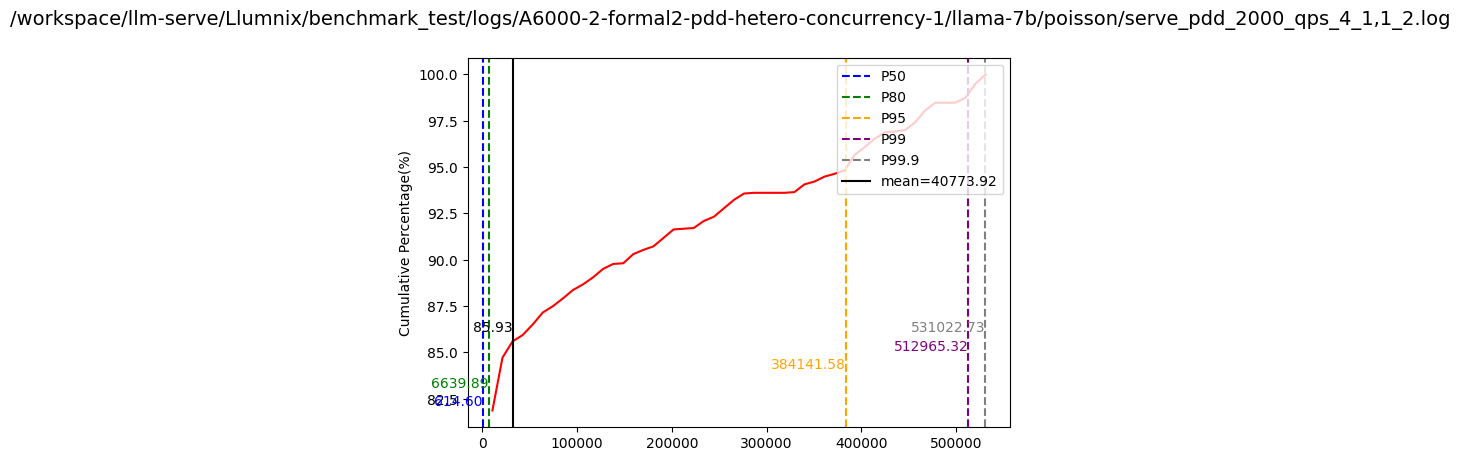

In [28]:
_ = extract_migration_waiting_times('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-1/llama-7b/poisson/serve_pdd_2000_qps_4_1,1_2.log', True)